# SBV2 07 - Extraction Metrics

This notebook evaluates the OCR-first extraction path after Notebook 06 normalisation. It combines OCR text metrics, schema validity, price pairing, source-evidence completeness, exact synthetic ground truth, weak NYPL-style examples, and the Notebook 05 PaddleOCR-VL diagnostic comparison.

No model inference is run here. Notebook 07 is the measurement layer that prepares Notebook 08 readiness scoring.

## Contract

Inputs:

- `data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv`
- `data/interim/sandbox_v2/manifests/sbv2_04_ocr_sample_manifest.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_04_ocr_document_summary.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_05_baseline_vs_vl_comparison.csv`
- `data/processed/sandbox_v2/menu_generation_schema.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_06_schema_document_summary.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_06_schema_validation_issues.csv`

Outputs:

- `data/processed/sandbox_v2/extraction_metrics.csv`
- `data/processed/sandbox_v2/extraction_metrics.parquet`
- document/source metric audit tables under `outputs/sandbox_v2/audit_tables/`
- `outputs/figures/sandbox_v2/sbv2_07_extraction_quality.png`

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "sandbox_v2").exists():
    candidates = [parent for parent in ROOT.parents if (parent / "sandbox_v2").exists()]
    if candidates:
        ROOT = candidates[0]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

CACHE_DIR = Path(os.environ.get("MENUFORGE_CACHE_HOME", ROOT / ".cache")).resolve()
for env_name, relative_path in {
    "XDG_CACHE_HOME": "",
    "MPLCONFIGDIR": "matplotlib",
    "JUPYTER_CONFIG_DIR": "jupyter_config",
    "JUPYTER_DATA_DIR": "jupyter_data",
    "JUPYTER_RUNTIME_DIR": "jupyter_runtime",
    "IPYTHONDIR": "ipython",
}.items():
    target = (CACHE_DIR / relative_path) if relative_path else CACHE_DIR
    target.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(env_name, str(target))

print({"ROOT": str(ROOT), "CACHE_DIR": str(CACHE_DIR)})

{'ROOT': '/home/endy/menuforge', 'CACHE_DIR': '/home/endy/menuforge/.cache'}


In [2]:
RUN_METRICS = True

print({"RUN_METRICS": RUN_METRICS})

{'RUN_METRICS': True}


### Preflight

All required inputs should already exist after Notebooks 04, 05 and 06. The VLM comparison is diagnostic; if it is missing, Notebook 07 can still score OCR/schema outputs.

In [3]:
preflight = {
    "sbv2_03_manifest": (ROOT / "data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv").exists(),
    "sbv2_04_ocr_sample": (ROOT / "data/interim/sandbox_v2/manifests/sbv2_04_ocr_sample_manifest.csv").exists(),
    "sbv2_04_ocr_doc_summary": (ROOT / "outputs/sandbox_v2/audit_tables/sbv2_04_ocr_document_summary.csv").exists(),
    "sbv2_05_vl_comparison_optional": (ROOT / "outputs/sandbox_v2/audit_tables/sbv2_05_baseline_vs_vl_comparison.csv").exists(),
    "sbv2_06_schema": (ROOT / "data/processed/sandbox_v2/menu_generation_schema.csv").exists(),
    "sbv2_06_schema_doc_summary": (ROOT / "outputs/sandbox_v2/audit_tables/sbv2_06_schema_document_summary.csv").exists(),
    "sbv2_06_validation": (ROOT / "outputs/sandbox_v2/audit_tables/sbv2_06_schema_validation_issues.csv").exists(),
}
for name, ok in preflight.items():
    print(f"  {'OK ' if ok else 'MISS'}  {name}")
required = [
    "sbv2_03_manifest", "sbv2_04_ocr_sample", "sbv2_04_ocr_doc_summary",
    "sbv2_06_schema", "sbv2_06_schema_doc_summary", "sbv2_06_validation",
]
missing = [name for name in required if not preflight[name]]
if missing:
    raise FileNotFoundError(f"Preflight failed; missing required inputs: {missing}")

  OK   sbv2_03_manifest
  OK   sbv2_04_ocr_sample
  OK   sbv2_04_ocr_doc_summary
  OK   sbv2_05_vl_comparison_optional
  OK   sbv2_06_schema
  OK   sbv2_06_schema_doc_summary
  OK   sbv2_06_validation


In [4]:
from sandbox_v2.extraction_metrics import write_outputs

summary_path = ROOT / "outputs" / "sandbox_v2" / "audit_tables" / "sbv2_07_extraction_metrics_summary.json"
if RUN_METRICS:
    summary = write_outputs()
elif summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
else:
    raise FileNotFoundError("RUN_METRICS is false and no previous SBV2 07 summary exists.")

print(json.dumps({
    "sample_rows": summary.get("sample_rows"),
    "document_metric_rows": summary.get("document_metric_rows"),
    "menu_documents": summary.get("menu_documents"),
    "exact_ground_truth_docs": summary.get("exact_ground_truth_docs"),
    "weak_ground_truth_docs": summary.get("weak_ground_truth_docs"),
    "ocr_reference_docs": summary.get("ocr_reference_docs"),
    "mean_extraction_quality": summary.get("mean_extraction_quality"),
    "figure": summary.get("figure"),
}, indent=2))

{
  "sample_rows": 8,
  "document_metric_rows": 8,
  "menu_documents": 3,
  "exact_ground_truth_docs": 1,
  "weak_ground_truth_docs": 2,
  "ocr_reference_docs": 2,
  "mean_extraction_quality": 0.9096,
  "figure": "outputs/figures/sandbox_v2/sbv2_07_extraction_quality.png"
}


In [5]:
def _safe_read_csv(path, **kw):
    try:
        return pd.read_csv(path, **kw)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()

doc_metrics = _safe_read_csv(ROOT / summary["document_metrics_csv"], low_memory=False)
source_metrics = _safe_read_csv(ROOT / summary["source_metrics_csv"], low_memory=False)
coverage = _safe_read_csv(ROOT / summary["metric_coverage_csv"], low_memory=False)

display(Markdown("### Metric Coverage"))
display(coverage)

display(Markdown("### Source Metrics"))
display(source_metrics)

display(Markdown("### Document Metrics"))
display(doc_metrics)

display(Markdown("### Generation-Candidate Menu Metrics"))
candidate_cols = [
    "unified_document_id", "source_id", "metric_ground_truth_level",
    "schema_rows", "priced_rows", "schema_validity_rate", "price_pairing_rate",
    "section_structure_rate", "manual_review_rate", "exact_item_name_coverage",
    "exact_price_coverage", "weak_example_item_coverage", "schema_quality_score",
    "extraction_quality_score", "metric_notes",
]
display(doc_metrics[doc_metrics["include_in_menu_extraction"].astype(bool)][candidate_cols])

### Metric Coverage

,coverage_type,metric,documents
0,ground_truth_level,exact_menu_ground_truth,1
1,ground_truth_level,no_ground_truth,3
2,ground_truth_level,ocr_text_reference,2
3,ground_truth_level,weak_menu_examples,2
4,metric_available,ocr_error_rates,2
5,metric_available,exact_menu_item_price_coverage,1
6,metric_available,weak_menu_example_coverage,3
7,metric_available,schema_validity,5


### Source Metrics

,source_id,documents,menu_documents,total_schema_rows,total_item_rows,total_priced_rows,total_review_rows,mean_text_quality,mean_schema_quality,mean_extraction_quality,mean_schema_validity,mean_price_pairing,mean_manual_review_rate
0,cord,1,0,0,0,0,0,0.8789,NaN,0.8789,NaN,NaN,NaN
1,funsd,1,0,0,0,0,0,0.8991,NaN,0.8991,NaN,NaN,NaN
2,nypl,1,1,33,33,33,12,0.8755,0.7620,0.8187,0.6364,1.0,0.3636
3,nypl_expanded,1,1,123,123,123,4,0.9523,0.9423,0.9473,0.9675,1.0,0.0325
4,sroie,1,0,0,0,0,0,0.8356,NaN,0.8356,NaN,NaN,NaN
5,synthetic_menu_concepts,1,1,10,10,10,0,0.9952,0.9996,0.9974,1.0000,1.0,0.0000
6,wikimedia_commons_english_menus,1,0,37,37,37,1,0.9423,NaN,0.9423,0.9730,1.0,0.0270
7,wikimedia_english_menus,1,0,74,74,74,3,0.9575,NaN,0.9575,0.9595,1.0,0.0405


### Document Metrics

,unified_document_id,source_id,document_id,dataset_family,task_family,evaluation_scope,metric_ground_truth_level,include_in_menu_extraction,ocr_status,ocr_line_count,...,weak_example_item_coverage,weak_example_total,vl_region_count,vl_text_char_count,vl_runtime_seconds,vl_diagnostic_status,text_quality_score,schema_quality_score,extraction_quality_score,metric_notes
0,sroie__sroie_00000,sroie,sroie_00000,receipt,receipt_kv_ocr,receipt_kv_ground_truth,ocr_text_reference,False,ok,45,...,NaN,NaN,1.0,1.0,53.898,vl_weaker_than_ocr,0.8356,NaN,0.8356,non-menu document: OCR text quality only; sche...
1,funsd__funsd_0,funsd,funsd_0,form,form_kv_ocr,form_kv_ground_truth,ocr_text_reference,False,ok,27,...,NaN,NaN,1.0,839.0,50.101,vl_coarser_than_ocr,0.8991,NaN,0.8991,non-menu document: OCR text quality only; sche...
2,nypl__nypl_page_45078,nypl,nypl_page_45078,menu,menu_ocr_extraction,menu_extraction_candidate,weak_menu_examples,True,ok,56,...,0.0,8.0,1.0,20.0,54.404,vl_weaker_than_ocr,0.8755,0.7620,0.8187,menu ground truth is weak/example-only; exact ...
3,nypl_expanded__nypl_expanded_144,nypl_expanded,nypl_expanded_144,menu,menu_ocr_extraction,menu_extraction_candidate,weak_menu_examples,True,ok,138,...,0.7,10.0,1.0,20.0,54.452,vl_weaker_than_ocr,0.9523,0.9423,0.9473,menu ground truth is weak/example-only; exact ...
4,synthetic_menu_concepts__synthetic_menu_concep...,synthetic_menu_concepts,synthetic_menu_concept_0000,menu,menu_ocr_extraction,menu_extraction_candidate,exact_menu_ground_truth,True,ok,38,...,1.0,10.0,1.0,555.0,45.459,vl_coarser_than_ocr,0.9952,0.9996,0.9974,PaddleOCR-VL retained as diagnostic only
5,wikimedia_commons_english_menus__wikimedia_com...,wikimedia_commons_english_menus,wikimedia_commons_0000,menu,menu_ocr_extraction,ocr_layout_sidecar,no_ground_truth,False,ok,247,...,NaN,NaN,1.0,38.0,52.965,vl_weaker_than_ocr,0.9423,NaN,0.9423,sidecar/non-generation document: schema rows a...
6,wikimedia_english_menus__wikimedia_menu_000,wikimedia_english_menus,wikimedia_menu_000,menu,menu_ocr_extraction,ocr_layout_sidecar,no_ground_truth,False,ok,845,...,NaN,NaN,1.0,44.0,53.118,vl_weaker_than_ocr,0.9575,NaN,0.9575,sidecar/non-generation document: schema rows a...
7,cord__cord_smoke_0000,cord,cord_smoke_0000,receipt,receipt_line_item_smoke,ocr_layout_sidecar,no_ground_truth,False,ok,89,...,NaN,NaN,1.0,440.0,54.313,vl_coarser_than_ocr,0.8789,NaN,0.8789,non-menu document: OCR text quality only; sche...


### Generation-Candidate Menu Metrics

,unified_document_id,source_id,metric_ground_truth_level,schema_rows,priced_rows,schema_validity_rate,price_pairing_rate,section_structure_rate,manual_review_rate,exact_item_name_coverage,exact_price_coverage,weak_example_item_coverage,schema_quality_score,extraction_quality_score,metric_notes
2,nypl__nypl_page_45078,nypl,weak_menu_examples,33,33,0.6364,1.0,1.0000,0.3636,NaN,NaN,0.0,0.7620,0.8187,menu ground truth is weak/example-only; exact ...
3,nypl_expanded__nypl_expanded_144,nypl_expanded,weak_menu_examples,123,123,0.9675,1.0,0.9431,0.0325,NaN,NaN,0.7,0.9423,0.9473,menu ground truth is weak/example-only; exact ...
4,synthetic_menu_concepts__synthetic_menu_concep...,synthetic_menu_concepts,exact_menu_ground_truth,10,10,1.0000,1.0,1.0000,0.0000,1.0,1.0,1.0,0.9996,0.9974,PaddleOCR-VL retained as diagnostic only


### Extraction Quality Figure

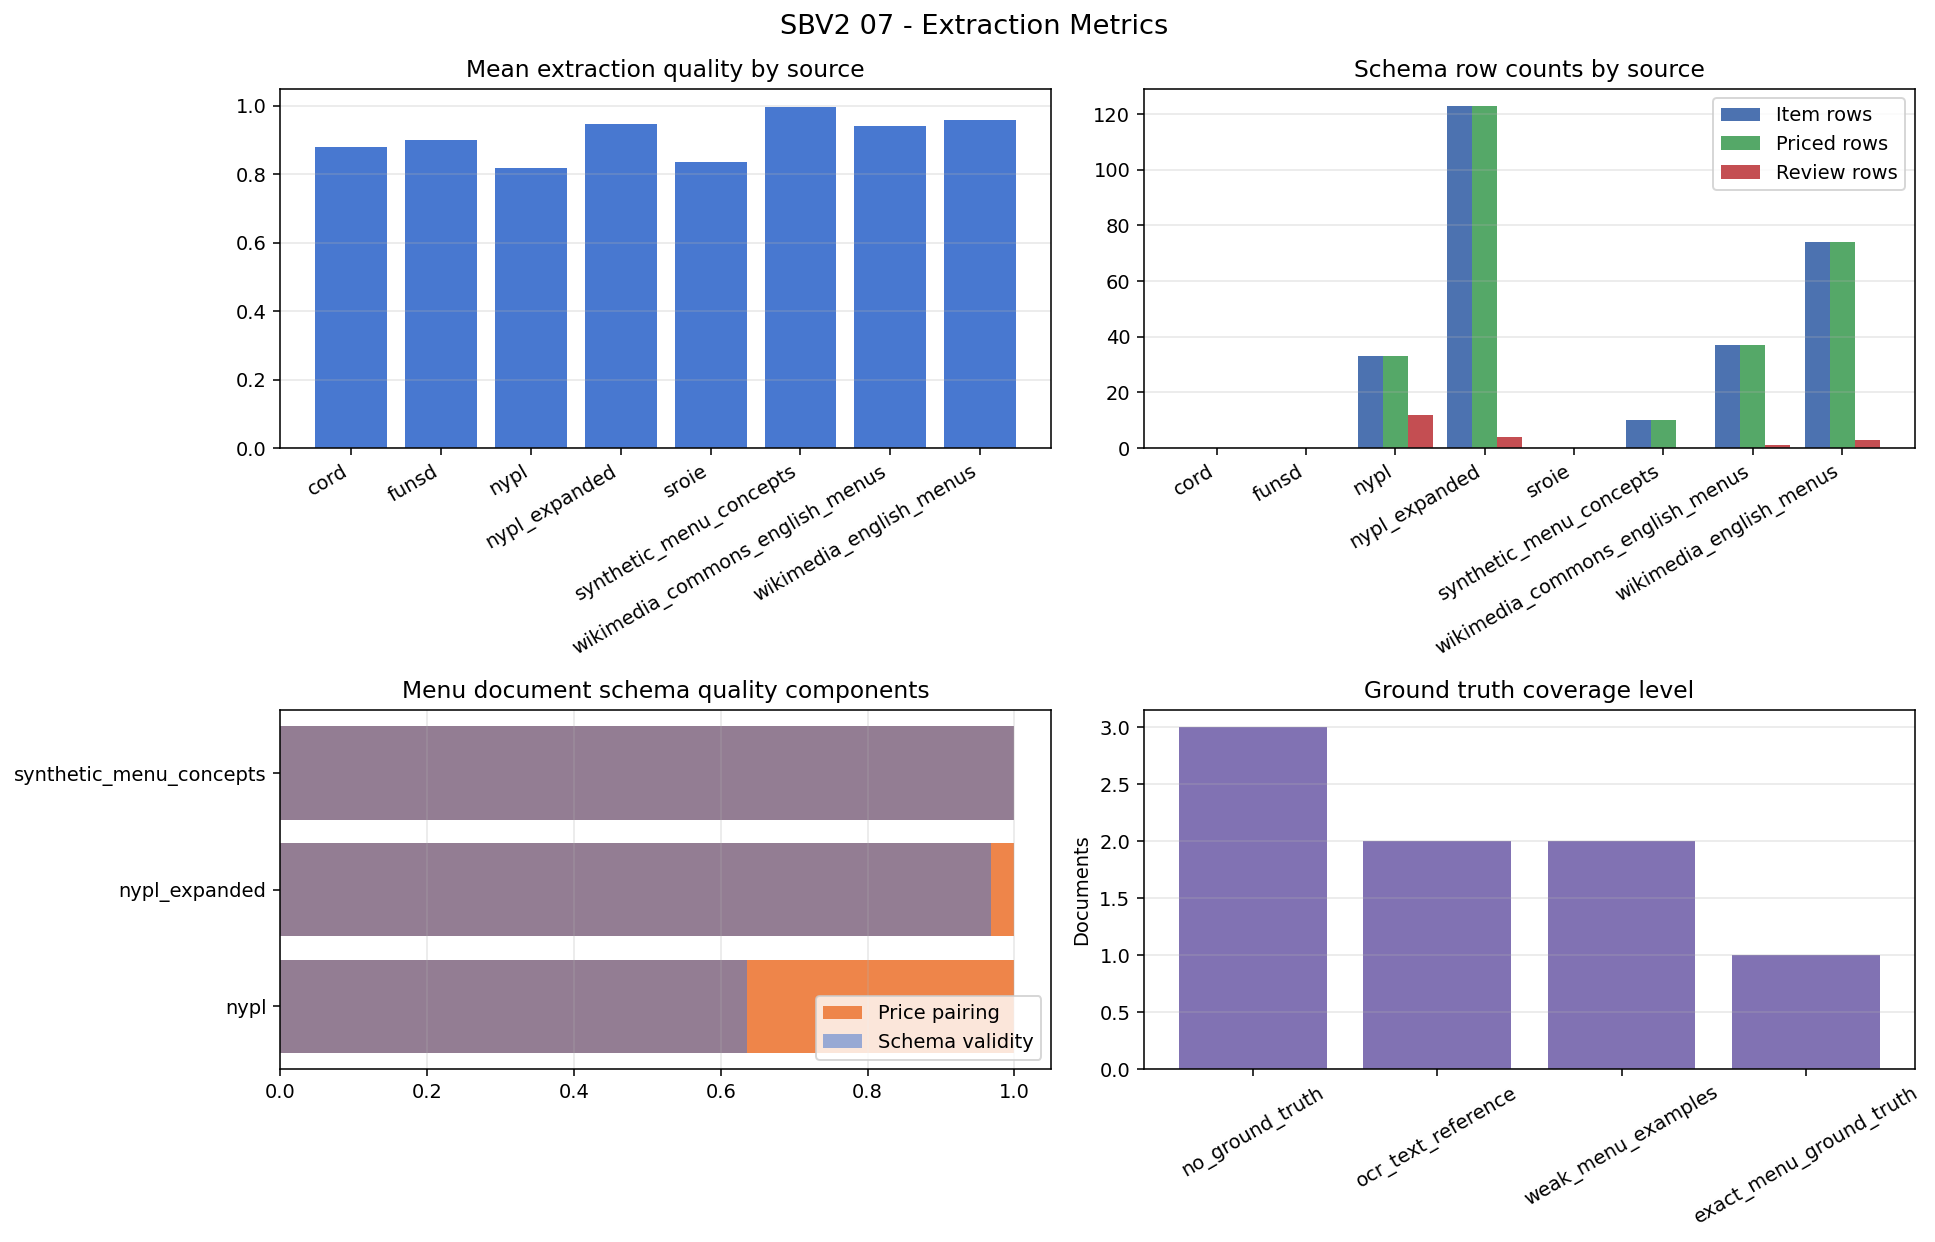

In [6]:
figure = summary.get("figure")
if figure and (ROOT / figure).exists():
    display(Markdown("### Extraction Quality Figure"))
    display(Image(filename=str(ROOT / figure)))
else:
    display(Markdown("_Extraction quality figure was not produced._"))

## Interpretation

- Exact menu item/price coverage is only claimed where exact synthetic ground truth exists.
- NYPL menu metrics use weak example coverage because page-to-dish alignment is partial and should not be overstated.
- SROIE and FUNSD are OCR/layout robustness checks, not menu generation candidates.
- Wikimedia and CORD sidecars can produce smoke-test rows or OCR signals, but they should not drive generation readiness without verified licensing/ground truth.
- PaddleOCR-VL remains diagnostic only because Notebook 05 produced coarser/weaker output than the OCR baseline.

## Handoff to Notebook 08

Notebook 08 should read `data/processed/sandbox_v2/extraction_metrics.csv` and classify each document as `ready_for_generation`, `needs_review`, or `do_not_generate`.

Suggested readiness inputs from this notebook:

- `text_quality_score`
- `schema_quality_score`
- `schema_validity_rate`
- `price_pairing_rate`
- `section_structure_rate`
- `source_evidence_rate`
- `manual_review_rate`
- `metric_ground_truth_level`
- source role/licence fields from the manifest